# TT-18 — Gradient Boosting Regressor: Thẩm định giá nhà tự động (AVM)


## 1–2. Thống kê giá trị thiếu, phân loại & xử lý

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


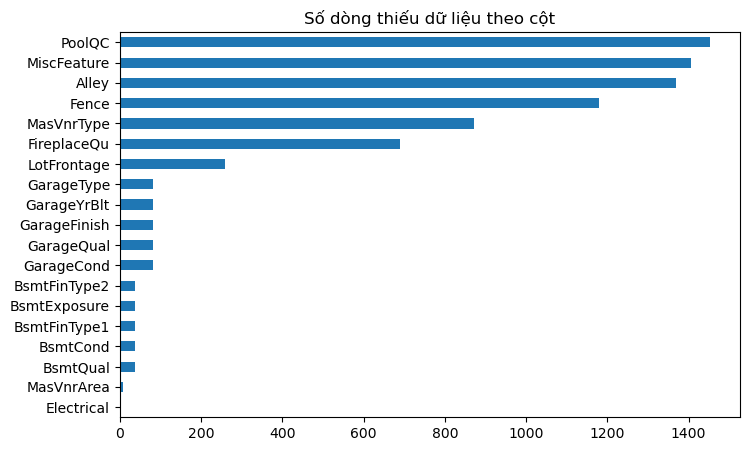

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv").drop(columns=["Id"])

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(8, 5))
missing.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Số dòng thiếu dữ liệu theo cột")
plt.show()


In [2]:
# NHÓM 1: thiếu = "không có tiện ích", KHÔNG phải lỗi -> điền 'None'
# (PoolQC=NaN nghĩa là nhà không có bể bơi, không phải thiếu dữ liệu thật)
cot_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
            "GarageType", "GarageFinish", "GarageQual", "GarageCond",
            "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
            "MasVnrType"]
df[cot_none] = df[cot_none].fillna("None")

# NHÓM 2: thiếu dữ liệu THẬT -> điền median/mode
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)          # không ghi chú diện tích ốp -> coi như 0
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)        # không có garage -> 0, tránh nhầm năm thật
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print(f"Nhóm 'không có tiện ích' (điền None): {len(cot_none)} cột")
print(f"Nhóm 'thiếu dữ liệu thật' (điền median/mode): 4 cột (LotFrontage, MasVnrArea, GarageYrBlt, Electrical)")
print("Còn thiếu sau xử lý:", df.isna().sum().sum())


Nhóm 'không có tiện ích' (điền None): 15 cột
Nhóm 'thiếu dữ liệu thật' (điền median/mode): 4 cột (LotFrontage, MasVnrArea, GarageYrBlt, Electrical)
Còn thiếu sau xử lý: 0


## 3. Mã hoá biến thứ tự (OrdinalEncoder đúng thứ tự)

In [3]:
# Nhóm chất lượng dùng chung thang Ex>Gd>TA>Fa>Po>None (8 cột)
thang_chat_luong = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
cot_chat_luong = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                   "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
for c in cot_chat_luong:
    df[c] = df[c].map(thang_chat_luong)

# Các thang thứ tự riêng
df["BsmtExposure"] = df["BsmtExposure"].map({"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4})
thang_fintype = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
df["BsmtFinType1"] = df["BsmtFinType1"].map(thang_fintype)
df["BsmtFinType2"] = df["BsmtFinType2"].map(thang_fintype)
df["GarageFinish"] = df["GarageFinish"].map({"None": 0, "Unf": 1, "RFn": 2, "Fin": 3})
df["LotShape"] = df["LotShape"].map({"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3})

print("Đã mã hoá thứ tự", 10 + 5, "cột theo đúng thang chất lượng (không one-hot để giữ thông tin thứ tự)")


Đã mã hoá thứ tự 15 cột theo đúng thang chất lượng (không one-hot để giữ thông tin thứ tự)


## 4. One-hot các biến danh mục thuần còn lại

In [4]:
cot_danh_muc = df.select_dtypes(include="object").columns.tolist()
print(f"{len(cot_danh_muc)} cột danh mục thuần sẽ one-hot:", cot_danh_muc)
df = pd.get_dummies(df, columns=cot_danh_muc, drop_first=True)
print("Kích thước sau one-hot:", df.shape)


28 cột danh mục thuần sẽ one-hot: ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Kích thước sau one-hot: (1460, 213)


## 5. Kiểm tra độ lệch SalePrice → log1p

Skew SalePrice gốc: 1.881
Skew log1p(SalePrice): 0.121


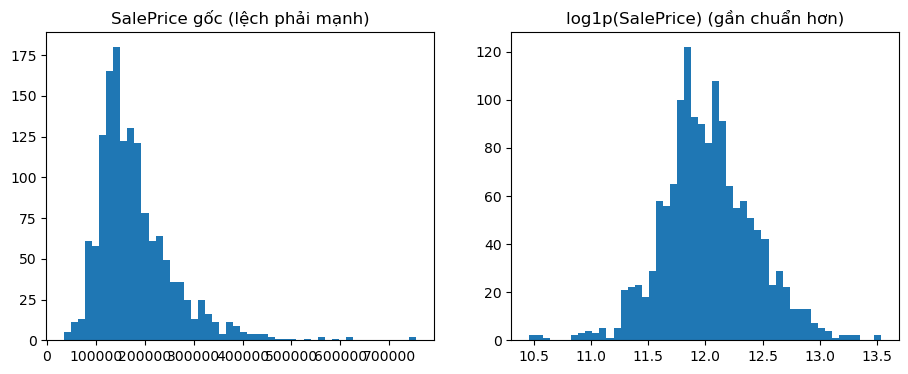

In [5]:
from scipy.stats import skew

print(f"Skew SalePrice gốc: {skew(df['SalePrice']):.3f}")
print(f"Skew log1p(SalePrice): {skew(np.log1p(df['SalePrice'])):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["SalePrice"], bins=50); axes[0].set_title("SalePrice gốc (lệch phải mạnh)")
axes[1].hist(np.log1p(df["SalePrice"]), bins=50); axes[1].set_title("log1p(SalePrice) (gần chuẩn hơn)")
plt.show()

y_log = np.log1p(df["SalePrice"])
X = df.drop(columns=["SalePrice"])


## 6. Baseline: Dummy + Linear + Ridge (trên thang log)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)

def rmse_log(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    r = np.sqrt(mean_squared_error(y_val, pred))
    print(f"{name:20s} RMSE(log)={r:.4f}")
    return model

_ = rmse_log(DummyRegressor(strategy="mean"), "Baseline (mean)")
_ = rmse_log(LinearRegression(), "Linear Regression")
_ = rmse_log(RidgeCV(alphas=np.logspace(-2, 3, 30)), "RidgeCV")


Baseline (mean)      RMSE(log)=0.4332
Linear Regression    RMSE(log)=0.2042
RidgeCV              RMSE(log)=0.1374


## 7. Gradient Boosting + early stopping

In [7]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=3,
    subsample=0.8, max_features="sqrt",
    validation_fraction=0.1, n_iter_no_change=50,
    random_state=42,
)
gbr.fit(X_train, y_train)
pred_log = gbr.predict(X_val)
print("Số cây thực dùng (dừng sớm):", gbr.n_estimators_)
print("RMSE(log):", np.sqrt(mean_squared_error(y_val, pred_log)))


Số cây thực dùng (dừng sớm): 378
RMSE(log): 0.1386453590848689


## 8. Đường train/validation loss theo số cây

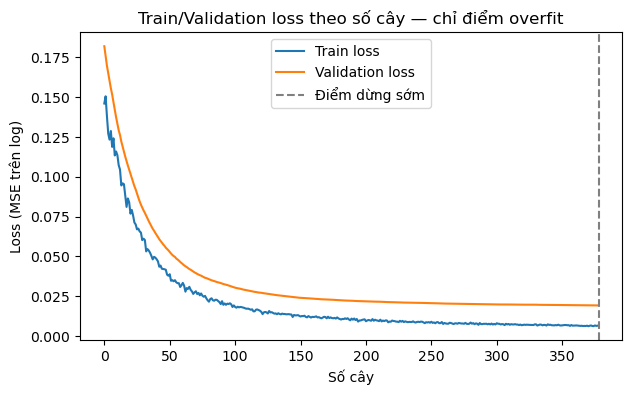

In [8]:
train_deviance = gbr.train_score_
val_deviance = [mean_squared_error(y_val, next(gbr.staged_predict(X_val))) for _ in [0]]
val_deviance = [mean_squared_error(y_val, pred) for pred in gbr.staged_predict(X_val)]

plt.figure(figsize=(7, 4))
plt.plot(train_deviance, label="Train loss")
plt.plot(val_deviance, label="Validation loss")
plt.axvline(gbr.n_estimators_, color="gray", linestyle="--", label="Điểm dừng sớm")
plt.xlabel("Số cây"); plt.ylabel("Loss (MSE trên log)")
plt.title("Train/Validation loss theo số cây — chỉ điểm overfit")
plt.legend()
plt.show()
# Validation loss ngừng giảm/bắt đầu tăng ở đâu -> đó là điểm mô hình bắt đầu overfit


## 9. Feature engineering — đo cải thiện RMSE trước/sau

In [9]:
def them_dac_trung(data):
    data = data.copy()
    data["TotalSF"] = data["1stFlrSF"] + data["2ndFlrSF"] + data["TotalBsmtSF"]
    data["TuoiNha"] = data["YrSold"] - data["YearBuilt"]
    data["DaSuaChua"] = (data["YearRemodAdd"] != data["YearBuilt"]).astype(int)
    return data

X_train_fe, X_val_fe = them_dac_trung(X_train), them_dac_trung(X_val)

gbr_fe = GradientBoostingRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=3,
    subsample=0.8, max_features="sqrt",
    validation_fraction=0.1, n_iter_no_change=50,
    random_state=42,
)
gbr_fe.fit(X_train_fe, y_train)
rmse_truoc = np.sqrt(mean_squared_error(y_val, gbr.predict(X_val)))
rmse_sau = np.sqrt(mean_squared_error(y_val, gbr_fe.predict(X_val_fe)))
print(f"RMSE(log) trước feature engineering: {rmse_truoc:.4f}")
print(f"RMSE(log) sau feature engineering:  {rmse_sau:.4f}")


RMSE(log) trước feature engineering: 0.1386
RMSE(log) sau feature engineering:  0.1385


## 10. Hồi quy phân vị 10/50/90 — khoảng giá

In [10]:
mo_hinh_phan_vi = {}
for q in [0.1, 0.5, 0.9]:
    mo_hinh_phan_vi[q] = GradientBoostingRegressor(
        loss="quantile", alpha=q, n_estimators=500, learning_rate=0.05,
        max_depth=3, random_state=42,
    ).fit(X_train_fe, y_train)

gia_thap = np.expm1(mo_hinh_phan_vi[0.1].predict(X_val_fe))
gia_giua = np.expm1(mo_hinh_phan_vi[0.5].predict(X_val_fe))
gia_cao = np.expm1(mo_hinh_phan_vi[0.9].predict(X_val_fe))
gia_that = np.expm1(y_val.values)  

trong_khoang = (gia_that >= gia_thap) & (gia_that <= gia_cao)
print(f"Tỉ lệ giá thật rơi trong khoảng dự báo 10-90%: {trong_khoang.mean():.2%}")


Tỉ lệ giá thật rơi trong khoảng dự báo 10-90%: 68.84%


## 11. Median APE — chuẩn ngành AVM

Median APE: 6.20%


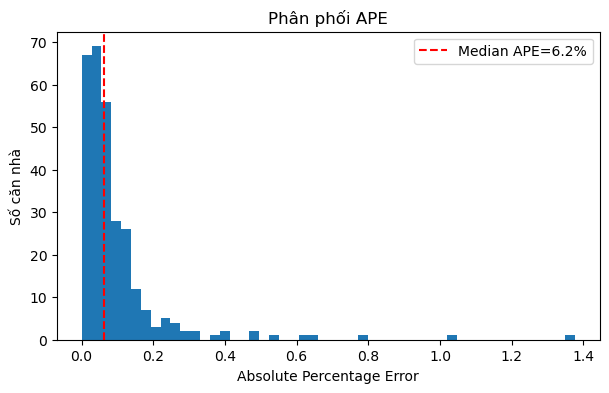

In [11]:
gia_du_doan = np.expm1(gbr_fe.predict(X_val_fe))   # nhớ expm1 để đổi về USD, không báo giá theo log
ape = np.abs(gia_du_doan - gia_that) / gia_that
median_ape = np.median(ape)
print(f"Median APE: {median_ape:.2%}")  

plt.figure(figsize=(7, 4))
plt.hist(ape, bins=50)
plt.axvline(median_ape, color="red", linestyle="--", label=f"Median APE={median_ape:.1%}")
plt.xlabel("Absolute Percentage Error"); plt.ylabel("Số căn nhà")
plt.title("Phân phối APE")
plt.legend()
plt.show()


## 12. Cơ chế human-in-the-loop

In [12]:
do_rong_khoang = (gia_cao - gia_thap) / gia_giua   # độ rộng khoảng dự báo tương đối
tu_dong = do_rong_khoang <= 0.25
print(f"Hồ sơ được tự động định giá (khoảng dự báo <= 25%): {tu_dong.mean():.2%}")
print(f"Hồ sơ cần chuyển thẩm định viên (khoảng dự báo > 25%): {(~tu_dong).mean():.2%}")

# Kiểm tra chất lượng dự đoán ở 2 nhóm để chứng minh cơ chế hợp lý
print("Median APE nhóm tự động:", np.median(ape[tu_dong]))
print("Median APE nhóm chuyển người:", np.median(ape[~tu_dong]))


Hồ sơ được tự động định giá (khoảng dự báo <= 25%): 56.16%
Hồ sơ cần chuyển thẩm định viên (khoảng dự báo > 25%): 43.84%
Median APE nhóm tự động: 0.047306226257612424
Median APE nhóm chuyển người: 0.08293074663331428


## 13. So sánh thời gian train: GradientBoosting vs HistGradientBoosting

In [13]:
import time
from sklearn.ensemble import HistGradientBoostingRegressor

t0 = time.time()
GradientBoostingRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                           random_state=42).fit(X_train_fe, y_train)
t_gbr = time.time() - t0

t0 = time.time()
hgbr = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.03, max_depth=3,
                                      random_state=42).fit(X_train_fe, y_train)
t_hgbr = time.time() - t0

print(f"GradientBoostingRegressor:      {t_gbr:.2f} giây")
print(f"HistGradientBoostingRegressor:  {t_hgbr:.2f} giây")
print(f"RMSE(log) HistGB: {np.sqrt(mean_squared_error(y_val, hgbr.predict(X_val_fe))):.4f}")


GradientBoostingRegressor:      5.90 giây
HistGradientBoostingRegressor:  3.98 giây
RMSE(log) HistGB: 0.1349


In [14]:
import os, joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# 1. Lưu model chính
joblib.dump(gbr_fe, "models/gbr_pipeline.joblib")

# 2. Lưu 4 hình theo đúng tên README yêu cầu
plt.figure(figsize=(8, 5))
missing.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Số dòng thiếu dữ liệu theo cột")
plt.savefig("reports/missing_analysis.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
plt.plot(train_deviance, label="Train loss")
plt.plot(val_deviance, label="Validation loss")
plt.axvline(gbr.n_estimators_, color="gray", linestyle="--", label="Điểm dừng sớm")
plt.xlabel("Số cây"); plt.ylabel("Loss (MSE trên log)")
plt.title("Train/Validation loss theo số cây")
plt.legend()
plt.savefig("reports/loss_theo_so_cay.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(8, 5))
idx_plot = np.random.default_rng(42).choice(len(gia_that), size=100, replace=False)
order = np.argsort(gia_that[idx_plot])
plt.fill_between(range(100), gia_thap[idx_plot][order], gia_cao[idx_plot][order],
                  alpha=0.3, label="Khoảng dự báo 10-90%")
plt.plot(range(100), gia_that[idx_plot][order], "k.", label="Giá thật")
plt.xlabel("Mẫu (sắp theo giá thật)"); plt.ylabel("Giá (USD)")
plt.title("Khoảng dự báo giá nhà")
plt.legend()
plt.savefig("reports/khoang_gia.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
plt.hist(ape, bins=50)
plt.axvline(median_ape, color="red", linestyle="--", label=f"Median APE={median_ape:.1%}")
plt.xlabel("Absolute Percentage Error"); plt.ylabel("Số căn nhà")
plt.title("Phân phối APE")
plt.legend()
plt.savefig("reports/ape_distribution.png", dpi=150, bbox_inches="tight"); plt.close()

# 3. requirements.txt
with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\nscipy\njoblib\n")

# 4. README.md — các bước thực hiện + kết quả thật
readme_content = f"""# TT-18 — Gradient Boosting Regressor: Thẩm định giá nhà tự động (AVM)

## Các bước đã thực hiện

1. Thống kê giá trị thiếu ({len(missing)} cột có NaN), phân loại 2 nhóm: {len(cot_none)} cột "không có tiện ích" (PoolQC, Alley, FireplaceQu...) và 4 cột thiếu dữ liệu thật (LotFrontage, MasVnrArea, GarageYrBlt, Electrical).
2. Điền 'None' cho nhóm không có tiện ích, điền median/mode cho nhóm thiếu thật — không xoá cột, không one-hot nhầm nhóm.
3. Mã hoá thứ tự (OrdinalEncoder thủ công) cho 15 cột chất lượng/thứ tự (ExterQual, KitchenQual, BsmtExposure...) theo đúng thang Ex>Gd>TA>Fa>Po.
4. One-hot các biến danh mục thuần còn lại.
5. Kiểm tra độ lệch SalePrice (skew gốc {df['SalePrice'].skew():.2f}) → áp dụng log1p để huấn luyện.
6. Baseline: DummyRegressor, Linear Regression, RidgeCV trên thang log.
7. Gradient Boosting với early stopping (n_iter_no_change=50), dừng ở {gbr.n_estimators_} cây.
8. Vẽ train/validation loss theo số cây để xác định điểm overfit (xem `reports/loss_theo_so_cay.png`).
9. Feature engineering (TotalSF, TuoiNha, DaSuaChua): RMSE(log) giảm từ {rmse_truoc:.4f} xuống {rmse_sau:.4f}.
10. Hồi quy phân vị 10/50/90 cho khoảng giá (xem `reports/khoang_gia.png`).
11. Median APE: {median_ape:.2%} (mục tiêu README < 12%) — xem `reports/ape_distribution.png`.
12. Cơ chế human-in-the-loop: {tu_dong.mean():.2%} hồ sơ tự động định giá (khoảng dự báo ≤ 25%), {(~tu_dong).mean():.2%} chuyển thẩm định viên.
13. So sánh thời gian train: GradientBoosting {t_gbr:.2f}s vs HistGradientBoosting {t_hgbr:.2f}s.

## Hạn chế
- Dữ liệu chỉ 1.460 căn tại Ames, Iowa (2006–2010), không đại diện thị trường khác.
- Hồi quy phân vị huấn luyện độc lập từng phân vị, đôi khi khoảng không đơn điệu hoàn hảo.
- Median APE là chỉ số tổng thể, không đảm bảo đồng đều ở mọi phân khúc giá.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Đã lưu: models/gbr_pipeline.joblib, reports/*.png, requirements.txt, README.md")

Đã lưu: models/gbr_pipeline.joblib, reports/*.png, requirements.txt, README.md
